# Notebook 03 — Probe → Embed → PCA + Ghazal cohesion + Affect coherence (v1.3)

This notebook takes the validated **beyt-level annotations** and produces **embedding-based diagnostics**:

**Inputs**
- Annotations: `../data/annotations/beyt_annotations_v1_3.jsonl`
- Embedding model: `SentenceTransformer("BAAI/bge-m3")` with `normalize_embeddings=True`

**Probes**
- **Main probe** (for PCA / UMAP / affect analyses): `beyt_hint | affect_tokens | ghazal_axis`
- **Cohesion probe A** (for ghazal cohesion): `beyt_hint`
- **Cohesion probe B** (optional comparison): `beyt_hint | affect_tokens`

**Outputs**
- Parquet embeddings saved under `../data/embeddings/`
- Figures saved under `../data/reports/03_probe_and_embed/` **and** `../assets/plots/`
- CSV diagnostics (trustworthiness sweep, cohesion stats, affect lift tables) saved alongside figures


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# Plots
import matplotlib.pyplot as plt

# -------------------------
# Paths (run this notebook from notebooks/)
# -------------------------
ANNOT_PATH = Path("../data/annotations/beyt_annotations_v1_3.jsonl")
assert ANNOT_PATH.exists(), f"Missing annotations: {ANNOT_PATH.resolve()}"

EMB_DIR    = Path("../data/embeddings")
REPORT_DIR = Path("../data/reports/03_probe_and_embed")
ASSETS_DIR = Path("../assets/plots")

for d in [EMB_DIR, REPORT_DIR, ASSETS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Embedding model
# -------------------------
EMBED_MODEL_NAME = "BAAI/bge-m3"
MODEL_TAG = "bge_m3"
VERSION_TAG = "v1_3"

# Embedding artifacts (wide parquet: poem_id, beyt_id, e0000..e1023)
EMB_MAIN_PATH        = EMB_DIR / f"{MODEL_TAG}__probe_main__{VERSION_TAG}.parquet"
EMB_HINT_ONLY_PATH   = EMB_DIR / f"{MODEL_TAG}__probe_hint_only__{VERSION_TAG}.parquet"
EMB_HINT_AFFECT_PATH = EMB_DIR / f"{MODEL_TAG}__probe_hint_affect__{VERSION_TAG}.parquet"

print("ANNOT_PATH:", ANNOT_PATH)
print("EMB_DIR:", EMB_DIR)
print("REPORT_DIR:", REPORT_DIR)
print("ASSETS_DIR:", ASSETS_DIR)
print("Embedding model:", EMBED_MODEL_NAME)

# -------------------------
# RTL helpers (Persian in matplotlib)
# -------------------------
def _rtl(s: str) -> str:
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display
        return get_display(arabic_reshaper.reshape(str(s)))
    except Exception:
        return str(s)

# Optional: set a Persian-friendly font if present
try:
    plt.rcParams["font.family"] = "Tahoma"
except Exception:
    pass

def savefig_both(fig, name: str, dpi: int = 200):
    p1 = REPORT_DIR / name
    p2 = ASSETS_DIR / name
    fig.savefig(p1, dpi=dpi, bbox_inches="tight")
    fig.savefig(p2, dpi=dpi, bbox_inches="tight")
    print("Saved:", p1)
    print("Saved:", p2)



ANNOT_PATH: ../data/annotations/beyt_annotations_v1_3.jsonl
EMB_DIR: ../data/embeddings
REPORT_DIR: ../data/reports/03_probe_and_embed
ASSETS_DIR: ../assets/plots
Embedding model: BAAI/bge-m3


In [2]:
# -------------------------
# 1) Load annotations + build probes
# -------------------------

def _normalize_affect(x) -> List[str]:
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return [t.strip() for t in map(str, x) if str(t).strip()]
    raise TypeError(f"Expected affect as list, got {type(x)}")

def load_annotations(path: Path) -> pd.DataFrame:
    df = pd.read_json(path, lines=True)
    df.columns = [c.strip() for c in df.columns]

    required = ["poem_id", "beyt_id", "beyt_hint", "ghazal_axis", "affect"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Columns: {list(df.columns)}")

    # clean types
    df["poem_id"] = df["poem_id"].astype(int)
    df["beyt_id"] = df["beyt_id"].astype(int)
    df["beyt_hint"] = df["beyt_hint"].astype(str).str.strip()
    df["ghazal_axis"] = df["ghazal_axis"].astype(str).str.strip()
    df["affect"] = df["affect"].apply(_normalize_affect)

    # derived fields
    df["affect_len"] = df["affect"].apply(len)
    df["affect_str"] = df["affect"].apply(lambda xs: " ".join(xs).strip())

    # ---- probes ----
    # Cohesion probe A
    df["probe_hint_only"] = df["beyt_hint"]

    # Cohesion probe B (optional comparison): hint | affect_tokens
    df["probe_hint_affect"] = df.apply(
        lambda r: r["beyt_hint"] if not r["affect_str"] else f"{r['beyt_hint']} | {r['affect_str']}",
        axis=1,
    )

    # Main probe: hint | affect_tokens | axis  (no labels like 'affect:' / 'axis:')
    df["probe_main"] = df.apply(
        lambda r: f"{r['beyt_hint']} | {r['ghazal_axis']}" if not r["affect_str"]
        else f"{r['beyt_hint']} | {r['affect_str']} | {r['ghazal_axis']}",
        axis=1,
    )

    # stable order + de-dupe (defensive)
    df = (
        df.drop_duplicates(["poem_id", "beyt_id"], keep="first")
          .sort_values(["poem_id", "beyt_id"])
          .reset_index(drop=True)
    )
    return df

df = load_annotations(ANNOT_PATH)

print("Rows:", len(df))
print("Non-empty affect:", int((df["affect_len"] > 0).sum()))
print("Non-empty ghazal_axis:", int((df["ghazal_axis"].str.len() > 0).sum()))
print("\nAffect cardinality distribution (0/1/2):")
print(df["affect_len"].value_counts().sort_index())

print("\nProbe examples:")
cols = ["poem_id","beyt_id","probe_hint_only","probe_hint_affect","probe_main"]
print(df[cols].head(3).to_string(index=False))

Rows: 4192
Non-empty affect: 3896
Non-empty ghazal_axis: 4192

Affect cardinality distribution (0/1/2):
affect_len
0     296
1    2056
2    1840
Name: count, dtype: int64

Probe examples:
 poem_id  beyt_id                       probe_hint_only                                  probe_hint_affect                                                                 probe_main
       1        1 درخواست شراب از ساقی، بیان دشواری عشق درخواست شراب از ساقی، بیان دشواری عشق | حسرت اندوه درخواست شراب از ساقی، بیان دشواری عشق | حسرت اندوه | پیچیدگی راه و منزلگاه
       1        2    انتظار پیام معشوق و تاثیر زلف معطر      انتظار پیام معشوق و تاثیر زلف معطر | شوق حسرت      انتظار پیام معشوق و تاثیر زلف معطر | شوق حسرت | پیچیدگی راه و منزلگاه
       1        3         ناپایداری اقامت در منزل معشوق      ناپایداری اقامت در منزل معشوق | بی‌قراری حسرت      ناپایداری اقامت در منزل معشوق | بی‌قراری حسرت | پیچیدگی راه و منزلگاه


In [3]:
# -------------------------
# 2) Embed probes + persist (wide parquet)
# -------------------------

import re
from sklearn.preprocessing import normalize

_ST_MODEL = None  # cache in-notebook

def embed_texts(texts: List[str], model_name: str, batch_size: int = 64) -> np.ndarray:
    global _ST_MODEL
    try:
        from sentence_transformers import SentenceTransformer
    except Exception as e:
        raise RuntimeError("Install sentence-transformers in your venv: pip install sentence-transformers") from e

    if _ST_MODEL is None:
        _ST_MODEL = SentenceTransformer(model_name)

    X = _ST_MODEL.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    X = np.asarray(X, dtype=np.float32)
    # defensive: ensure L2 norm ≈ 1
    X = normalize(X, norm="l2", axis=1).astype(np.float32)
    return X

def _emb_cols(d: int) -> List[str]:
    return [f"e{i:04d}" for i in range(d)]

def save_embeddings_wide_parquet(keys: pd.DataFrame, X: np.ndarray, out_path: Path):
    assert X.ndim == 2
    out = keys[["poem_id","beyt_id"]].copy()
    cols = _emb_cols(X.shape[1])
    emb_df = pd.DataFrame(X, columns=cols)
    out = pd.concat([out.reset_index(drop=True), emb_df], axis=1)

    try:
        out.to_parquet(out_path, index=False)
    except Exception as e:
        raise RuntimeError(f"Failed to write parquet to {out_path}. Install pyarrow: pip install pyarrow") from e

    print(f"Saved {out_path} | X.shape={X.shape}")

def load_embeddings_wide_parquet(path: Path) -> Tuple[pd.DataFrame, np.ndarray]:
    df_e = pd.read_parquet(path)
    if not {"poem_id","beyt_id"}.issubset(df_e.columns):
        raise ValueError(f"Missing keys in embeddings parquet: {path}")

    emb_cols = [c for c in df_e.columns if re.fullmatch(r"e\d{4}", str(c))]
    emb_cols = sorted(emb_cols)
    if not emb_cols:
        raise ValueError(f"No embedding columns found (e0000..). Columns: {list(df_e.columns)[:10]} ...")

    X = df_e[emb_cols].to_numpy(dtype=np.float32)
    keys = df_e[["poem_id","beyt_id"]].copy()
    return keys, X

def get_or_make_embeddings(probe_col: str, out_path: Path) -> Tuple[pd.DataFrame, np.ndarray]:
    if out_path.exists():
        keys, X = load_embeddings_wide_parquet(out_path)
        return keys, X

    texts = df[probe_col].tolist()
    keys = df[["poem_id","beyt_id"]].copy()
    X = embed_texts(texts, model_name=EMBED_MODEL_NAME, batch_size=64)
    save_embeddings_wide_parquet(keys, X, out_path)
    return keys, X

# --- Build / load embeddings ---
keys_main, X_main = get_or_make_embeddings("probe_main", EMB_MAIN_PATH)
keys_hint, X_hint = get_or_make_embeddings("probe_hint_only", EMB_HINT_ONLY_PATH)
keys_hint_aff, X_hint_affect = get_or_make_embeddings("probe_hint_affect", EMB_HINT_AFFECT_PATH)

print("Main embeddings:", X_main.shape)
print("Hint-only embeddings:", X_hint.shape)
print("Hint|affect embeddings:", X_hint_affect.shape)

# Sanity: key alignment should match the annotation DF order
assert (keys_main["poem_id"].to_numpy() == df["poem_id"].to_numpy()).all()
assert (keys_main["beyt_id"].to_numpy() == df["beyt_id"].to_numpy()).all()

Main embeddings: (4192, 1024)
Hint-only embeddings: (4192, 1024)
Hint|affect embeddings: (4192, 1024)


X_main shape: (4192, 1024)
k80=120  k90=203  k95=287
Saved: ../data/reports/03_probe_and_embed/pca_explained_variance_curve.csv
Saved: ../assets/plots/pca_explained_variance_curve.csv
Saved: ../data/reports/03_probe_and_embed/pca_explained_variance_curve.png
Saved: ../assets/plots/pca_explained_variance_curve.png


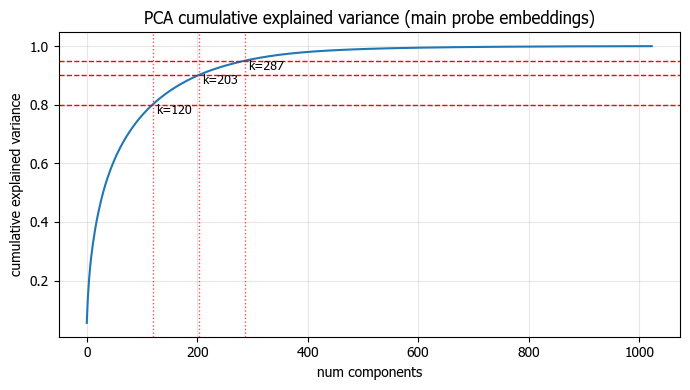

In [4]:
# -------------------------
# 3) PCA on MAIN embeddings (diagnostic, not a replacement embedding)
# -------------------------

from sklearn.decomposition import PCA

assert isinstance(X_main, np.ndarray) and X_main.ndim == 2
n, d = X_main.shape
print("X_main shape:", X_main.shape)

pca = PCA(n_components=d, svd_solver="full", random_state=0)
pca.fit(X_main)

evr = pca.explained_variance_ratio_
explained_full = np.cumsum(evr)

def k_for(target: float) -> int:
    return int(np.searchsorted(explained_full, target) + 1)

k80, k90, k95 = k_for(0.80), k_for(0.90), k_for(0.95)
print(f"k80={k80}  k90={k90}  k95={k95}")

# Save curve data
curve = pd.DataFrame({
    "k": np.arange(1, d + 1),
    "explained_variance_ratio": evr,
    "cumulative_explained_variance": explained_full,
})
csv_name = "pca_explained_variance_curve.csv"
curve.to_csv(REPORT_DIR / csv_name, index=False, encoding="utf-8")
curve.to_csv(ASSETS_DIR / csv_name, index=False, encoding="utf-8")
print("Saved:", REPORT_DIR / csv_name)
print("Saved:", ASSETS_DIR / csv_name)

# Plot (style matches what you described)
plt.figure(figsize=(7,4))
plt.plot(explained_full)

plt.axhline(0.80, color="red", linestyle="--", linewidth=1)
plt.axhline(0.90, color="red", linestyle="--", linewidth=1)
plt.axhline(0.95, color="red", linestyle="--", linewidth=1)

plt.grid(True, alpha=0.3)
plt.title("PCA cumulative explained variance (main probe embeddings)")
plt.xlabel("num components")
plt.ylabel("cumulative explained variance")
plt.tight_layout()
for k, y in [(k80, 0.80), (k90, 0.90), (k95, 0.95)]:
    plt.axvline(k, color="red", linestyle=":", linewidth=1, alpha=0.7)
    plt.text(k+5, y-0.03, f"k={k}", fontsize=9)

fig = plt.gcf()
savefig_both(fig, "pca_explained_variance_curve.png", dpi=200)
plt.show()

## Ghazal cohesion (diagnostic)

We **do not** want retrieval neighborhoods to be dominated by ghazal membership.

If embeddings were clustering whole ghazals together, many nearest neighbors of a beyt would come from the **same** `poem_id`.  
But Hafez ghazals often *shift topic and affect across couplets*, so **weak same-ghazal neighbor rates** (especially a median near 0) supports treating the **beyt** as the semantic unit.

We measure cohesion as:

- For each beyt, take its top-*k* nearest neighbors (cosine).
- Compute the fraction of those neighbors with the same `poem_id`.
- Compare against a **random baseline** implied by poem sizes.

We compute this on:
- **Probe A**: hint-only (primary)
- **Probe B**: hint|affect (optional comparison)


Random baseline (same-poem probability): 0.001874814442434807

Probe A (hint-only): {'mean': 0.008420801526717557, 'median': 0.0, 'p90': 0.05, 'p99': 0.1}
Probe B (hint|affect): {'mean': 0.00889790076335878, 'median': 0.0, 'p90': 0.05, 'p99': 0.1}

Saved: ../data/reports/03_probe_and_embed/ghazal_cohesion_rates_k20.csv
Saved: ../data/reports/03_probe_and_embed/ghazal_cohesion_hint_only_k20.png
Saved: ../assets/plots/ghazal_cohesion_hint_only_k20.png


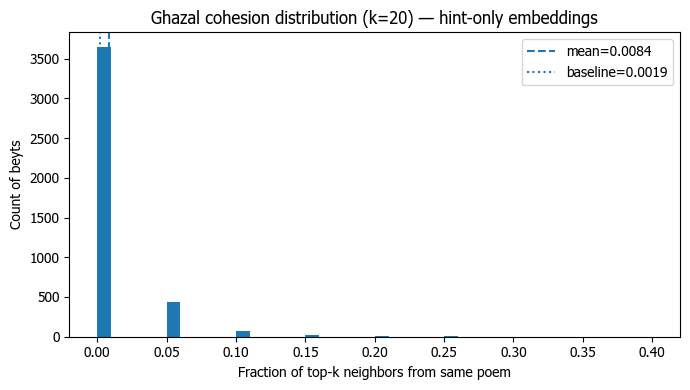

Saved: ../data/reports/03_probe_and_embed/ghazal_cohesion_hint_affect_k20.png
Saved: ../assets/plots/ghazal_cohesion_hint_affect_k20.png


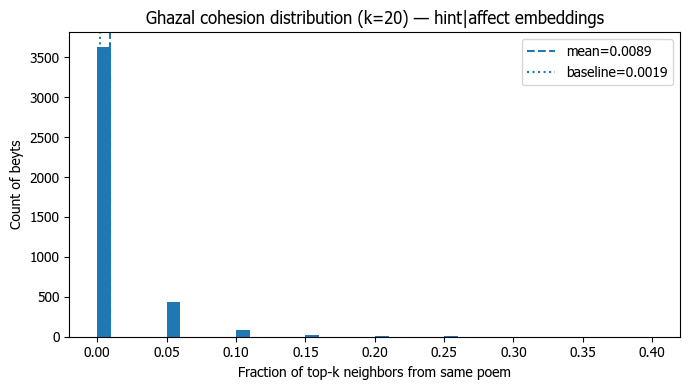

In [5]:
from sklearn.neighbors import NearestNeighbors

def random_baseline_same_poem(poem_ids: np.ndarray) -> float:
    N = len(poem_ids)
    vc = pd.Series(poem_ids).value_counts().to_numpy(dtype=np.int64)  # n_i
    # sum_i (n_i/N) * ((n_i-1)/(N-1))
    return float(((vc / N) * ((vc - 1) / (N - 1))).sum())

def ghazal_cohesion_rates(X: np.ndarray, poem_ids: np.ndarray, k: int = 20) -> np.ndarray:
    nn = NearestNeighbors(n_neighbors=k+1, metric="cosine")
    nn.fit(X)
    idx = nn.kneighbors(return_distance=False)[:, 1:]  # drop self
    same = (poem_ids[idx] == poem_ids[:, None])
    return same.mean(axis=1)

def summarize_rates(rates: np.ndarray) -> Dict[str, float]:
    return {
        "mean": float(rates.mean()),
        "median": float(np.median(rates)),
        "p90": float(np.quantile(rates, 0.90)),
        "p99": float(np.quantile(rates, 0.99)),
    }

k = 20
poem = df["poem_id"].to_numpy()
baseline = random_baseline_same_poem(poem)
print("Random baseline (same-poem probability):", baseline)

rates_hint = ghazal_cohesion_rates(X_hint, poem, k=k)
rates_hint_aff = ghazal_cohesion_rates(X_hint_affect, poem, k=k)

print("\nProbe A (hint-only):", summarize_rates(rates_hint))
print("Probe B (hint|affect):", summarize_rates(rates_hint_aff))

# Save CSV (useful for build_log + later comparisons)
out = pd.DataFrame({
    "poem_id": df["poem_id"],
    "beyt_id": df["beyt_id"],
    f"same_poem_rate_k{k}_hint_only": rates_hint,
    f"same_poem_rate_k{k}_hint_affect": rates_hint_aff,
})
csv_name = f"ghazal_cohesion_rates_k{k}.csv"
out.to_csv(REPORT_DIR / csv_name, index=False, encoding="utf-8")
print("\nSaved:", REPORT_DIR / csv_name)

# Plot distribution (hint-only) + baseline
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(rates_hint, bins=40)
ax.axvline(rates_hint.mean(), linestyle="--", label=f"mean={rates_hint.mean():.4f}")
ax.axvline(baseline, linestyle=":", label=f"baseline={baseline:.4f}")
ax.set_title(f"Ghazal cohesion distribution (k={k}) — hint-only embeddings")
ax.set_xlabel("Fraction of top-k neighbors from same poem")
ax.set_ylabel("Count of beyts")
ax.legend()
fig.tight_layout()
savefig_both(fig, f"ghazal_cohesion_hint_only_k{k}.png", dpi=200)
plt.show()

# Optional: plot hint|affect too
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(rates_hint_aff, bins=40)
ax.axvline(rates_hint_aff.mean(), linestyle="--", label=f"mean={rates_hint_aff.mean():.4f}")
ax.axvline(baseline, linestyle=":", label=f"baseline={baseline:.4f}")
ax.set_title(f"Ghazal cohesion distribution (k={k}) — hint|affect embeddings")
ax.set_xlabel("Fraction of top-k neighbors from same poem")
ax.set_ylabel("Count of beyts")
ax.legend()
fig.tight_layout()
savefig_both(fig, f"ghazal_cohesion_hint_affect_k{k}.png", dpi=200)
plt.show()

## UMAP (qualitative sanity check)

UMAP is not a proof, but it helps answer: **do labeled items concentrate in regions, or scatter uniformly?**

We:
1. Reduce `X_main` to 50 dims with PCA for speed (keeps most variance; UMAP cares about local neighborhoods).
2. Sweep a small grid and score each run with **trustworthiness** (how well 2D preserves original local neighborhoods).
3. Keep 2D layouts that are both high-trustworthiness and human-readable.


In [6]:
# -------------------------
# 4) UMAP sweep (trustworthiness) on MAIN embeddings
# -------------------------

# UMAP is an optional dependency
try:
    import umap
except Exception as e:
    raise RuntimeError("Install umap-learn: pip install umap-learn") from e

from sklearn.manifold import trustworthiness
from sklearn.decomposition import PCA

# Reduce to 50 dims for UMAP speed (diagnostic only)
pca50 = PCA(n_components=50, random_state=0)
X50 = pca50.fit_transform(X_main).astype(np.float32)

grid = [
    (10, 0.00),
    (10, 0.05),
    (15, 0.00),
    (15, 0.05),
    (10, 0.10),
    (15, 0.10),
    (30, 0.00),
    (30, 0.10),
    (50, 0.00),
    (50, 0.05),
    (80, 0.00),
]

rows = []
for n_neighbors, min_dist in grid:
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=0,
    )
    Z = reducer.fit_transform(X50)

    tw = trustworthiness(X50, Z, n_neighbors=10)
    rows.append({"n_neighbors": n_neighbors, "min_dist": float(min_dist), "trustworthiness(n=10)": float(tw)})

tw_df = pd.DataFrame(rows).sort_values("trustworthiness(n=10)", ascending=False).reset_index(drop=True)
display(tw_df)

csv_name = "umap_trustworthiness_sweep.csv"
tw_df.to_csv(REPORT_DIR / csv_name, index=False, encoding="utf-8")
tw_df.to_csv(ASSETS_DIR / csv_name, index=False, encoding="utf-8")
print("Saved:", REPORT_DIR / csv_name)
print("Saved:", ASSETS_DIR / csv_name)


/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-p

,n_neighbors,min_dist,trustworthiness(n=10)
0,10,0.00,0.934924
1,15,0.00,0.931171
2,10,0.05,0.927378
3,15,0.05,0.921319
4,50,0.00,0.919953
5,10,0.10,0.917648
6,30,0.00,0.915795
7,15,0.10,0.911426
8,80,0.00,0.910639
9,50,0.05,0.908629


Saved: ../data/reports/03_probe_and_embed/umap_trustworthiness_sweep.csv
Saved: ../assets/plots/umap_trustworthiness_sweep.csv


Affect labels (by frequency):


حسرت        1483
شوق         1251
امید         752
اندوه        751
بی‌قراری     538
آرامش        450
حیرت         398
ناامیدی      113
Name: count, dtype: int64

/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP Z shape: (4192, 2)
Saved: ../data/reports/03_probe_and_embed/umap_story_30_0.1_multiaffect.png
Saved: ../assets/plots/umap_story_30_0.1_multiaffect.png


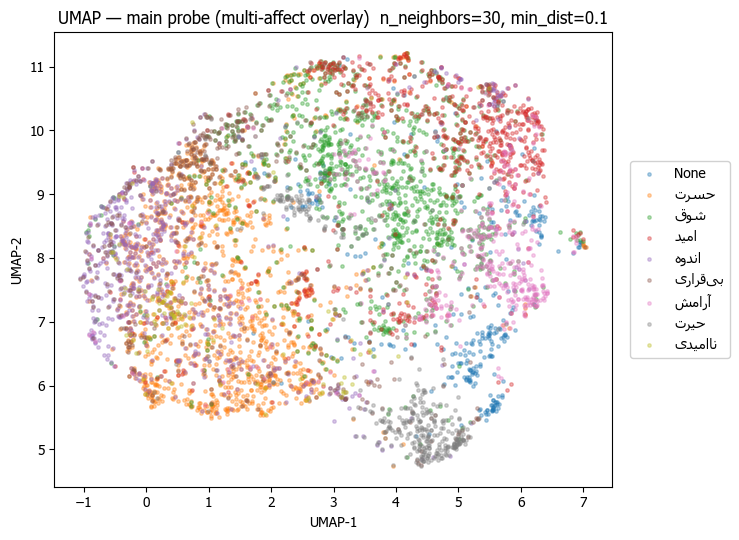

Saved: ../data/reports/03_probe_and_embed/umap_facets_main_30_0.1.png
Saved: ../assets/plots/umap_facets_main_30_0.1.png


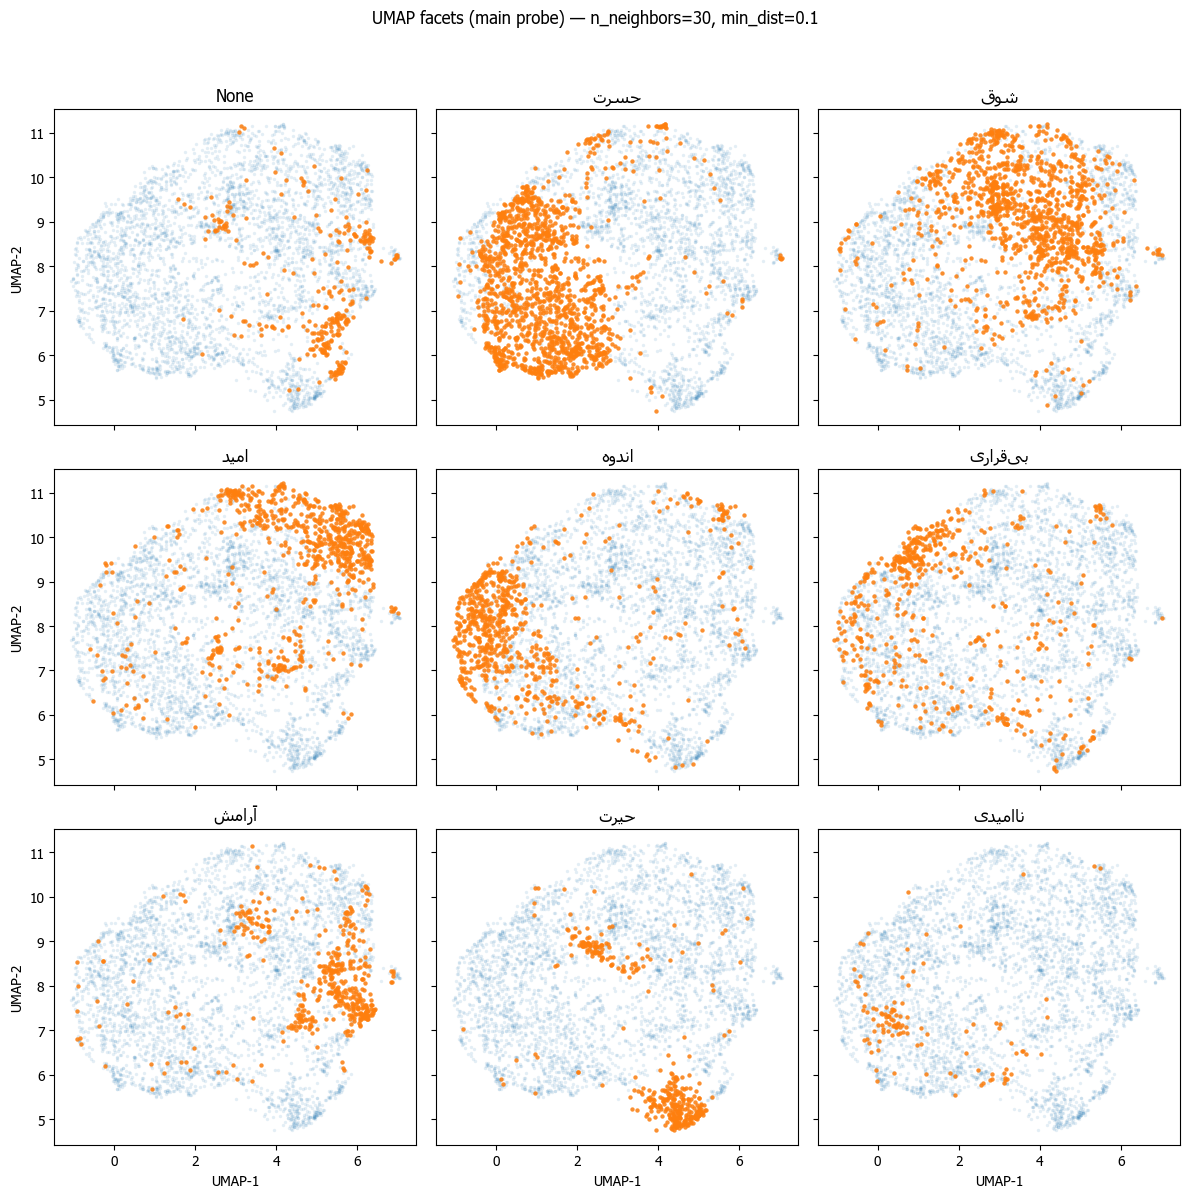

In [7]:
# -------------------------
# 5) UMAP plots (main probe) — multi-affect overlay + 9-panel facets
# -------------------------

# Affect labels (8 labels) + None
aff_counts = (
    pd.Series([a for xs in df["affect"].tolist() for a in xs])
    .value_counts()
)

affect_labels = aff_counts.index.tolist()
print("Affect labels (by frequency):")
display(aff_counts)

assert len(affect_labels) == 8, f"Expected 8 affect labels, got {len(affect_labels)}: {affect_labels}"

def compute_umap(X_in: np.ndarray, n_neighbors: int, min_dist: float, seed: int = 0) -> np.ndarray:
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=seed,
    )
    return reducer.fit_transform(X_in)

# Choose a "story" layout (human-readable) — you can change these and re-run
NN, MD = 30, 0.10
Z = compute_umap(X50, n_neighbors=NN, min_dist=MD, seed=0)
print("UMAP Z shape:", Z.shape)

# ---------- Multi-affect overlay (each label gets a point; 2-affect gets 2 points) ----------
# Deterministic tiny jitter only for multi-affect cases so both points are visible.
rng = np.random.default_rng(0)

rows = []
for i, (x, y) in enumerate(Z):
    affects = df.at[i, "affect"]
    if not affects:
        rows.append({"x": x, "y": y, "affect": "None", "is_multi": False})
    elif len(affects) == 1:
        rows.append({"x": x, "y": y, "affect": affects[0], "is_multi": False})
    else:
        # 2 affects: duplicate point with tiny jitter
        jx, jy = rng.normal(0, 0.006), rng.normal(0, 0.006)
        rows.append({"x": x + jx, "y": y + jy, "affect": affects[0], "is_multi": True})
        rows.append({"x": x - jx, "y": y - jy, "affect": affects[1], "is_multi": True})

df_multi = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for lab in ["None"] + affect_labels:
    sub = df_multi[df_multi["affect"] == lab]
    ax.scatter(sub["x"], sub["y"], s=6, alpha=0.35, label=_rtl(lab))
ax.set_title(_rtl(f"UMAP — main probe (multi-affect overlay)  n_neighbors={NN}, min_dist={MD}"))
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), framealpha=0.9)
fig.tight_layout()
savefig_both(fig, f"umap_story_{NN}_{MD}_multiaffect.png", dpi=200)
plt.show()

# ---------- 9-panel facets (background vs highlighted label) ----------
labels9 = ["None"] + affect_labels  # affect_labels = top8 affects in your chosen order

# UMAP coordinates
X0 = Z[:, 0]
Y0 = Z[:, 1]
N = len(df)

# Precompute boolean masks once (fast + deterministic)
affect_len = df["affect_len"].to_numpy()
mask_none = (affect_len == 0)

# Build an (N, n_affects) membership matrix for top8 affects
# This avoids df.apply inside the plotting loop.
aff_lists = df["affect"].tolist()
aff_idx = {a: i for i, a in enumerate(affect_labels)}
M = np.zeros((N, len(affect_labels)), dtype=bool)
for i, xs in enumerate(aff_lists):
    for a in xs:
        j = aff_idx.get(a)
        if j is not None:
            M[i, j] = True

# Figure
fig, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=False)
axes = axes.ravel()

for i, (ax, lab) in enumerate(zip(axes, labels9)):
    # background (all points)
    ax.scatter(X0, Y0, s=6, alpha=0.12, linewidths=0)

    # highlighted mask
    if lab == "None":
        mask = mask_none
    else:
        mask = M[:, aff_idx[lab]]

    ax.scatter(X0[mask], Y0[mask], s=10, alpha=0.85, linewidths=0)

    ax.set_title(_rtl(lab), fontsize=12)

    # Only label outer axes to reduce clutter
    r, c = divmod(i, 3)
    if r == 2:
        ax.set_xlabel("UMAP-1")
    else:
        ax.set_xticklabels([])
    if c == 0:
        ax.set_ylabel("UMAP-2")
    else:
        ax.set_yticklabels([])

# Title (keep English; if you want Persian, wrap with _rtl)
fig.suptitle(f"UMAP facets (main probe) — n_neighbors={NN}, min_dist={MD}", y=0.995)

# Leave room for suptitle
fig.tight_layout(rect=[0, 0, 1, 0.97])

# Save (use your unified helper; assets recommended for build_log)
savefig_both(fig, f"umap_facets_main_{NN}_{MD}.png", dpi=200)  # e.g., assets/plots/...
plt.show()
   

## Affect kNN coherence (quantitative label sanity check)

UMAP is qualitative. Here we test: **do nearest-neighbor neighborhoods share affect labels more than chance?**

We compute, for each beyt with at least one affect label:
- **any-overlap rate**: fraction of its k nearest neighbors sharing *at least one* affect token.
- Compare to a **shuffle baseline** (same embedding geometry; affect sets permuted across beyts).
- Report **lift = real / shuffled**.

We also compute per-affect lift (top 8 affects) to see which labels are the most locally coherent.


,k,real_any_overlap_mean(labeled_only),shuffle_any_overlap_mean(labeled_only),lift(real/shuffle)
0,5,0.881520,0.295688,2.981250
1,10,0.876514,0.292094,3.000791
2,20,0.871073,0.295008,2.952712
3,50,0.857798,0.295406,2.903797


Saved: ../data/reports/03_probe_and_embed/affect_knn_any_overlap_lift.csv
Saved: ../data/reports/03_probe_and_embed/affect_knn_any_overlap_lift.png
Saved: ../assets/plots/affect_knn_any_overlap_lift.png


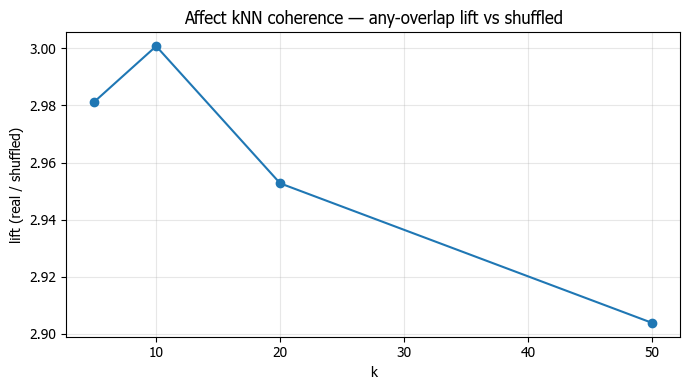

k,5,10,20,50
affect,,,,
آرامش,6.209607,5.831557,5.801289,5.437500
امید,3.931783,3.730015,3.685410,3.471605
اندوه,3.911411,4.021961,3.942240,3.829757
بی‌قراری,4.924419,4.777299,4.875652,4.737288
حسرت,2.436024,2.449175,2.439282,2.439701
حیرت,5.414530,5.390830,5.484571,5.240767
شوق,2.680736,2.701648,2.626614,2.553474
ناامیدی,11.421053,12.735294,12.042254,10.930636


Saved: ../data/reports/03_probe_and_embed/affect_knn_per_affect_lift.csv
Saved: ../data/reports/03_probe_and_embed/affect_knn_per_affect_lift.png
Saved: ../assets/plots/affect_knn_per_affect_lift.png


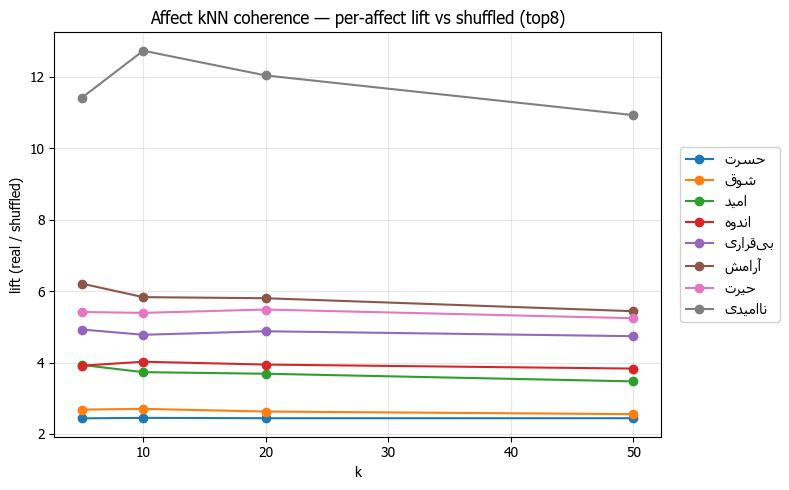

In [8]:
from sklearn.neighbors import NearestNeighbors

# Build neighbor graph once for max-k
KMAX = 50
nn = NearestNeighbors(n_neighbors=KMAX+1, metric="cosine")
nn.fit(X_main)
nbrs = nn.kneighbors(return_distance=False)[:, 1:]  # (N,KMAX)

aff_lists = df["affect"].tolist()
has_label = np.array([len(xs) > 0 for xs in aff_lists], dtype=bool)

def any_overlap_rate_for_k(nbr_idx: np.ndarray, aff: List[List[str]], k: int) -> np.ndarray:
    idx_k = nbr_idx[:, :k]
    out = np.zeros(len(aff), dtype=np.float32)
    for i in range(len(aff)):
        A = set(aff[i])
        if not A:
            out[i] = 0.0
            continue
        hits = 0
        for j in idx_k[i]:
            if A.intersection(aff[j]):
                hits += 1
        out[i] = hits / k
    return out

def shuffle_affects(aff: List[List[str]], seed: int = 0) -> List[List[str]]:
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(aff))
    return [aff[i] for i in perm]

Ks = [5, 10, 20, 50]

aff_shuf = shuffle_affects(aff_lists, seed=0)

rows = []
for k in Ks:
    real = any_overlap_rate_for_k(nbrs, aff_lists, k)
    shuf = any_overlap_rate_for_k(nbrs, aff_shuf, k)

    real_mean = float(real[has_label].mean())
    shuf_mean = float(shuf[has_label].mean())
    lift = real_mean / shuf_mean if shuf_mean > 0 else np.nan

    rows.append({
        "k": k,
        "real_any_overlap_mean(labeled_only)": real_mean,
        "shuffle_any_overlap_mean(labeled_only)": shuf_mean,
        "lift(real/shuffle)": lift,
    })

any_df = pd.DataFrame(rows)
display(any_df)

csv_name = "affect_knn_any_overlap_lift.csv"
any_df.to_csv(REPORT_DIR / csv_name, index=False, encoding="utf-8")
any_df.to_csv(ASSETS_DIR / csv_name, index=False, encoding="utf-8")
print("Saved:", REPORT_DIR / csv_name)

# Plot lift vs k
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(any_df["k"], any_df["lift(real/shuffle)"], marker="o")
ax.set_title(_rtl("Affect kNN coherence — any-overlap lift vs shuffled"))
ax.set_xlabel("k")
ax.set_ylabel("lift (real / shuffled)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
savefig_both(fig, "affect_knn_any_overlap_lift.png", dpi=200)
plt.show()

# ---- Per-affect lift (top 8) ----
affect_labels = [a for a in aff_counts.index.tolist()]  # same as earlier
label_mask = {a: np.array([a in xs for xs in aff_lists], dtype=bool) for a in affect_labels}

def per_label_rate(nbr_idx: np.ndarray, aff: List[List[str]], k: int, label: str) -> float:
    mask = label_mask[label]
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        return float("nan")
    idx_k = nbr_idx[idxs, :k]
    hits = 0
    total = len(idxs) * k
    for ii, neighs in zip(idxs, idx_k):
        for j in neighs:
            if label in aff[j]:
                hits += 1
    return hits / total

per_rows = []
for label in affect_labels:
    for k in Ks:
        r = per_label_rate(nbrs, aff_lists, k, label)
        s = per_label_rate(nbrs, aff_shuf, k, label)
        per_rows.append({"affect": label, "k": k, "real": r, "shuffle": s, "lift": (r/s if s>0 else np.nan)})

per_df = pd.DataFrame(per_rows)
display(per_df.pivot(index="affect", columns="k", values="lift"))

csv_name = "affect_knn_per_affect_lift.csv"
per_df.to_csv(REPORT_DIR / csv_name, index=False, encoding="utf-8")
per_df.to_csv(ASSETS_DIR / csv_name, index=False, encoding="utf-8")
print("Saved:", REPORT_DIR / csv_name)

# Plot per-affect lift curves (top8)
fig, ax = plt.subplots(figsize=(8,5))
for label in affect_labels:
    sub = per_df[per_df["affect"] == label].sort_values("k")
    ax.plot(sub["k"], sub["lift"], marker="o", label=_rtl(label))
ax.set_title(_rtl("Affect kNN coherence — per-affect lift vs shuffled (top8)"))
ax.set_xlabel("k")
ax.set_ylabel("lift (real / shuffled)")
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), framealpha=0.9)
fig.tight_layout()
savefig_both(fig, "affect_knn_per_affect_lift.png", dpi=200)
plt.show()

Affect centroid sizes:


حسرت        1483
شوق         1251
امید         752
اندوه        751
بی‌قراری     538
آرامش        450
حیرت         398
ناامیدی      113
dtype: int64

Within-affect tightness (mean cos to centroid):


ناامیدی     0.811896
بی‌قراری    0.790326
اندوه       0.785948
حسرت        0.775769
آرامش       0.765813
شوق         0.762841
حیرت        0.761205
امید        0.760854
dtype: float64

Saved: ../data/reports/03_probe_and_embed/affect_centroid_dendrogram.png
Saved: ../assets/plots/affect_centroid_dendrogram.png


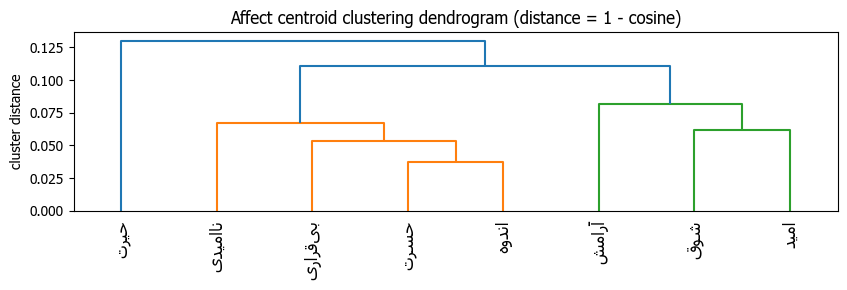

Saved: ../data/reports/03_probe_and_embed/affect_centroid_cosine_similarity_reordered.png
Saved: ../assets/plots/affect_centroid_cosine_similarity_reordered.png


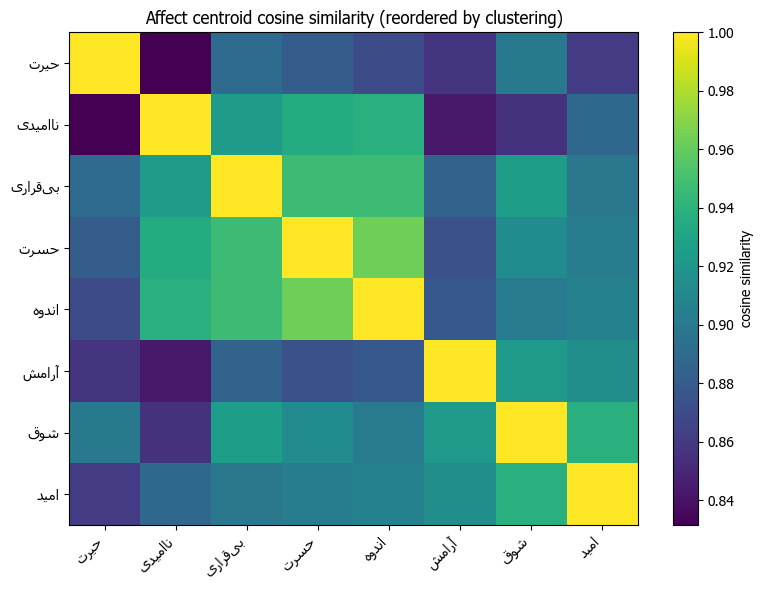

In [9]:
# -------------------------
# 6) Affect centroid analysis (main probe embeddings)
# -------------------------

from sklearn.metrics.pairwise import cosine_similarity

try:
    from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
    from scipy.spatial.distance import squareform
except Exception as e:
    raise RuntimeError("Install scipy for dendrograms: pip install scipy") from e

# Build centroids: mean embedding of all beyts that contain the label (multi-label membership allowed)
centroids = {}
sizes = {}
tightness = {}  # mean cosine to centroid

for label in affect_labels:
    mask = np.array([label in xs for xs in aff_lists], dtype=bool)
    sizes[label] = int(mask.sum())
    if sizes[label] == 0:
        continue
    C = X_main[mask].mean(axis=0)
    # normalize centroid
    C = C / (np.linalg.norm(C) + 1e-12)
    centroids[label] = C.astype(np.float32)

    sims = (X_main[mask] @ C)  # cosine because normalized
    tightness[label] = float(np.mean(sims))

sizes_s = pd.Series(sizes).sort_values(ascending=False)
tight_s = pd.Series(tightness).sort_values(ascending=False)

print("Affect centroid sizes:")
display(sizes_s)

print("Within-affect tightness (mean cos to centroid):")
display(tight_s)

# Centroid cosine similarity matrix
labels = sizes_s.index.tolist()
Cmat = np.vstack([centroids[l] for l in labels])
S = cosine_similarity(Cmat)
np.fill_diagonal(S, 1.0)

# Cluster centroids by distance = 1 - cosine
D = 1.0 - S
Zlink = linkage(squareform(D, checks=False), method="average")
order = leaves_list(Zlink)
labels_ord = [labels[i] for i in order]
S_ord = S[np.ix_(order, order)]

# Dendrogram
fig, ax = plt.subplots(figsize=(8.5, 3.0))
dendrogram(Zlink, labels=[_rtl(l) for l in labels], leaf_rotation=90, ax=ax)
ax.set_title(_rtl("Affect centroid clustering dendrogram (distance = 1 - cosine)"))
ax.set_ylabel("cluster distance")
fig.tight_layout()
savefig_both(fig, "affect_centroid_dendrogram.png", dpi=200)
plt.show()

# Reordered heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(S_ord, aspect="auto")
ax.set_xticks(range(len(labels_ord)))
ax.set_yticks(range(len(labels_ord)))
ax.set_xticklabels([_rtl(l) for l in labels_ord], rotation=45, ha="right")
ax.set_yticklabels([_rtl(l) for l in labels_ord])
ax.set_title(_rtl("Affect centroid cosine similarity (reordered by clustering)"))
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("cosine similarity")
fig.tight_layout()
savefig_both(fig, "affect_centroid_cosine_similarity_reordered.png", dpi=200)
plt.show()